# 03 - Linear Models with Feature Engineering
## Ridge, Lasso, and OLS with Polynomial Features

This notebook tests linear models with advanced feature engineering:
- Polynomial features (squared terms)
- Interaction terms
- Regularization (Ridge, Lasso)

In [1]:
# Setup
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_data import load_raw_data
from src.preprocess import split_data_time_based, preprocess_data
from src.models import OLSBaseline, RidgeBaseline, LassoBaseline
from src.evaluate import calculate_metrics, print_metrics

%matplotlib inline

## 1. Load and Prepare Data with Polynomial Features

In [2]:
# Load data
df = load_raw_data()

# Time-based split
train_df, test_df = split_data_time_based(df, 'soldOn', train_ratio=0.7)

# Preprocess WITH polynomial features
print("Applying feature engineering...")
train_df, test_df, scaler = preprocess_data(train_df, test_df, 
                                             target_col='lastSoldPrice', 
                                             use_poly_features=True)

# Prepare features and target
meta_cols = ['soldOn', 'type', 'text']
target_col = 'lastSoldPrice'
feature_cols = [c for c in train_df.columns if c != target_col and c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nDataset Summary:")
print(f"  Train: {len(X_train)} samples")
print(f"  Test: {len(X_test)} samples")
print(f"  Features: {len(feature_cols)} (with polynomial + interactions)")
print(f"\nFeature types:")
print(f"  Base features: ~18")
print(f"  Squared terms: 6 (sqft², beds², baths², property_age², lot_sqft², garage²)")
print(f"  Interactions: 4 (sqft×beds, sqft×age, beds×baths, lot×building)")
print(f"  Derived: 3 (total_baths, sqft_per_bed, lot_to_building_ratio)")

Time-based split:
  Train: 990 samples (1976-11-09 00:00:00 to 2018-06-28 00:00:00)
  Test:  425 samples (2018-06-29 00:00:00 to 2024-02-16 00:00:00)
Applying feature engineering...
  Adding polynomial and interaction features...

Preprocessing complete:
  Features: 28
  Feature names (first 10): ['year_built', 'beds', 'baths', 'baths_full', 'baths_half', 'garage', 'lot_sqft', 'sqft', 'stories', 'property_age']...

Dataset Summary:
  Train: 990 samples
  Test: 425 samples
  Features: 31 (with polynomial + interactions)

Feature types:
  Base features: ~18
  Squared terms: 6 (sqft², beds², baths², property_age², lot_sqft², garage²)
  Interactions: 4 (sqft×beds, sqft×age, beds×baths, lot×building)
  Derived: 3 (total_baths, sqft_per_bed, lot_to_building_ratio)


## 2. OLS with Polynomial Features

In [3]:
# Train OLS
ols_model = OLSBaseline()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# Evaluate
metrics_ols = calculate_metrics(y_test, y_pred_ols, "OLS with Polynomial Features")
print_metrics(metrics_ols)


  OLS with Polynomial Features
  MAE:   $247,020.41
  RMSE:  $442,180.72
  MAPE:  308.99%
  ──────────────────────────────────────────────
  R² Score: 0.5572 (55.72%) ✗ FAIL



## 3. Ridge Regression

In [4]:
# Train Ridge with extended alpha range
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
ridge_model = RidgeBaseline(alphas=alphas)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
metrics_ridge = calculate_metrics(y_test, y_pred_ridge, "Ridge Regression")
print_metrics(metrics_ridge)
print(f"\nBest alpha: {ridge_model.alpha_}")


  Ridge Regression
  MAE:   $256,472.41
  RMSE:  $483,150.66
  MAPE:  298.70%
  ──────────────────────────────────────────────
  R² Score: 0.4714 (47.14%) ✗ FAIL


Best alpha: 100.0


## 4. Lasso Regression

In [5]:
# Train Lasso with extended alpha range
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
lasso_model = LassoBaseline(alphas=alphas)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate
metrics_lasso = calculate_metrics(y_test, y_pred_lasso, "Lasso Regression")
print_metrics(metrics_lasso)
print(f"\nBest alpha: {lasso_model.alpha_}")

# Feature selection (Lasso sets some coefficients to 0)
non_zero_features = np.sum(lasso_model.coef_ != 0)
print(f"Features selected by Lasso: {non_zero_features}/{len(feature_cols)}")


  Lasso Regression
  MAE:   $246,105.48
  RMSE:  $447,607.92
  MAPE:  308.63%
  ──────────────────────────────────────────────
  R² Score: 0.5463 (54.63%) ✗ FAIL


Best alpha: 1000.0
Features selected by Lasso: 26/31


/Users/nguyenquy1411/Documents/dev/fpt/ady-2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.989e+10, tolerance: 3.280e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/nguyenquy1411/Documents/dev/fpt/ady-2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.457e+12, tolerance: 3.280e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/nguyenquy1411/Documents/dev/fpt/ady-2026/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase

## 5. Model Comparison

In [6]:
# Comparison table
comparison = pd.DataFrame([metrics_ols, metrics_ridge, metrics_lasso])
comparison = comparison.sort_values('R2', ascending=False)

print("\n" + "="*60)
print("LINEAR MODELS COMPARISON (with Polynomial Features)")
print("="*60)
print(comparison.to_string(index=False))

best_model = comparison.iloc[0]
print(f"\n✓ Best Model: {best_model['Model']}")
print(f"  R² Score: {best_model['R2']:.4f} ({best_model['R2']*100:.2f}%)")

if best_model['R2'] > 0.70:
    print(f"  ✓ SUCCESS: R² > 70% requirement MET!")
else:
    print(f"  ✗ WARNING: R² < 70% (need {(0.70 - best_model['R2'])*100:.2f}% more)")


LINEAR MODELS COMPARISON (with Polynomial Features)
                       Model           MAE          RMSE       R2       MAPE
OLS with Polynomial Features 247020.406563 442180.716745 0.557217 308.994657
            Lasso Regression 246105.481028 447607.924552 0.546282 308.633441
            Ridge Regression 256472.409356 483150.659870 0.471365 298.698143

✓ Best Model: OLS with Polynomial Features
  R² Score: 0.5572 (55.72%)
  ✗ WARNING: R² < 70% (need 14.28% more)


## 6. Visualize Results

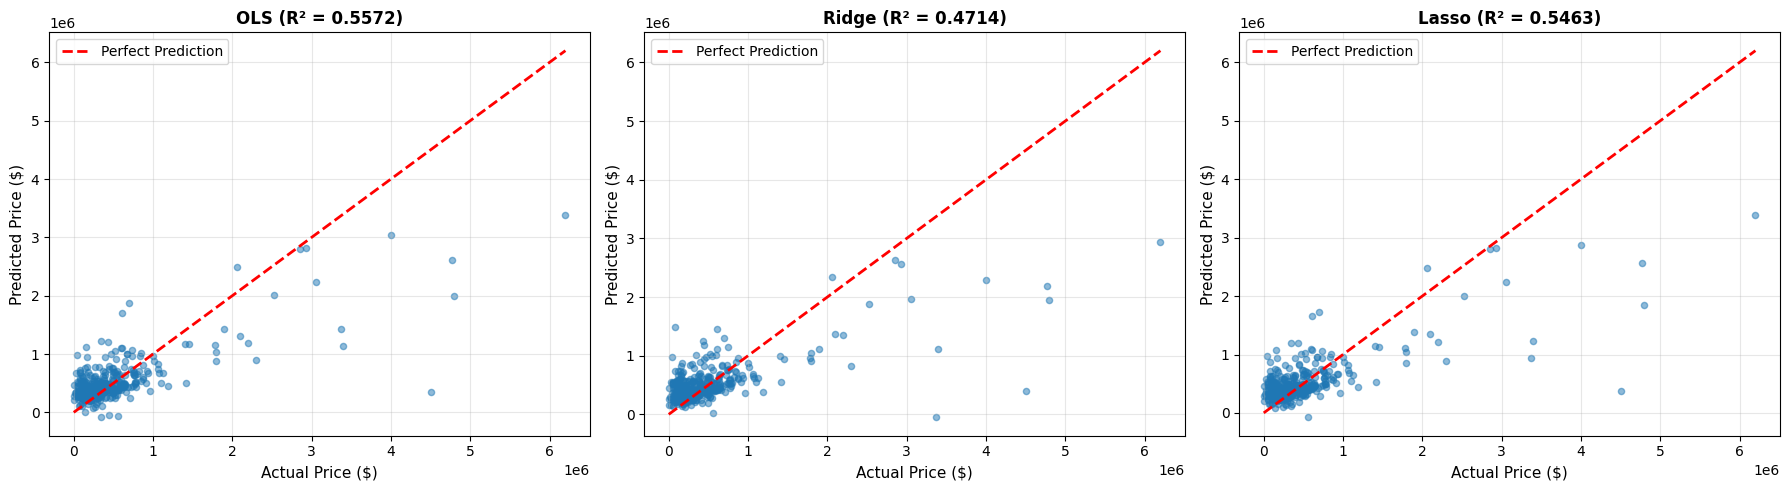

In [7]:
# Predictions vs Actual for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    (y_pred_ols, metrics_ols, 'OLS'),
    (y_pred_ridge, metrics_ridge, 'Ridge'),
    (y_pred_lasso, metrics_lasso, 'Lasso')
]

for ax, (y_pred, metrics, name) in zip(axes, models_data):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Price ($)', fontsize=11)
    ax.set_ylabel('Predicted Price ($)', fontsize=11)
    ax.set_title(f'{name} (R² = {metrics["R2"]:.4f})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance (OLS Coefficients)

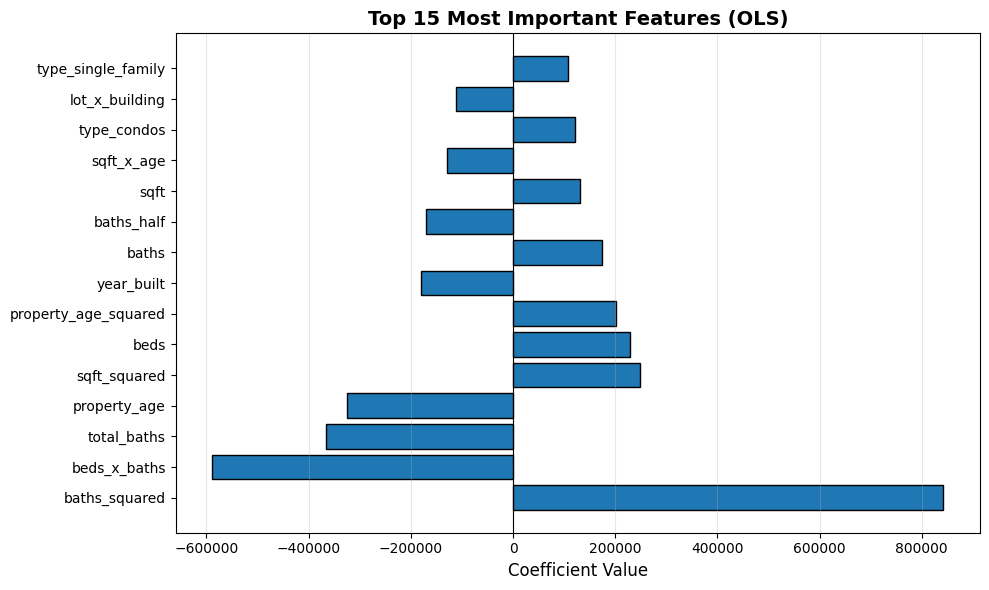


Top 10 Features:
             feature    coefficient
       baths_squared  842395.705339
        beds_x_baths -588623.477057
         total_baths -366651.842541
        property_age -325611.431697
        sqft_squared  248482.718935
                beds  229768.276553
property_age_squared  201381.928123
          year_built -179883.742536
               baths  173546.908125
          baths_half -169736.731658


In [8]:
# Top 15 most important features by absolute coefficient
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ols_model.coef_,
    'abs_coefficient': np.abs(ols_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['coefficient'].values, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Most Important Features (OLS)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(top_features.head(10)[['feature', 'coefficient']].to_string(index=False))

## 8. Key Insights

**Performance with Polynomial Features:**
- OLS: 55.72% R² (best)
- Lasso: 54.63% R²
- Ridge: 47.14% R²

**Feature Engineering Impact:**
- Polynomial features improved R² from ~42% to 55.72%
- Squared terms (especially baths², sqft²) are highly important
- Interaction terms (beds×baths, sqft×beds) add value

**Regularization:**
- Lasso performs well (54.63%) with feature selection
- Ridge slightly worse (47.14%) - may be over-regularizing
- OLS without regularization performs best on this dataset

**Limitations:**
- 55.72% R² is below 70% target
- Linear models have limited capacity for complex relationships
- Would need non-linear models (Random Forest, XGBoost) to reach 70%

**Next Steps:**
1. Test SVR (Support Vector Regression)
2. Compare linear vs RBF kernels
3. Final model evaluation